# 🌍 **Lumeria - Egypt Tourism User-Based Collaborative Filtering** 🇪🇬

> **Note:** This project implements a User-Based Collaborative Filtering Recommendation System using Cosine Similarity to suggest Egyptian tourist attractions for the Lumeria mobile application based on similar users' preferences.

<div align="center">
  <img src="https://pplx-res.cloudinary.com/image/upload/pplx_search_images/3d5d97094451768c8a00c422700eb0b6b2e3dc78.jpg" width="600">
</div>

---

# 🚨 **Project Overview**

This project applies **User-Based Collaborative Filtering** to build a personalized recommendation engine. By analyzing behavioral patterns and rating histories, the system identifies users with similar tastes and recommends places they have highly rated, ensuring a customized and dynamic experience for each user on the Lumeria app.

---

# **🔍 Data Preparation & Optimization**

- **Curated Datasets:** Integrated two main datasets: a comprehensive list of Egyptian places and a dataset of user ratings.
- **Data Cleansing:** Handled duplicate records to prevent skewed similarity distributions.
- **Data Filtering:** Removed inactive users and rarely visited places to reduce matrix sparsity and improve model accuracy.
- **Matrix Transformation:** Converted the data into a User-Item Pivot Table to represent user ratings across all locations mathematically.

---

# 🛠 **Technical Implementation**

**Core Technologies**
- **Framework:** Python, Pandas, Matplotlib, Seaborn (EDA) & Scikit-Learn (Machine Learning).
- **Algorithm:** Cosine Similarity.
- **Mathematical Foundation:** The similarity between two users $A$ and $B$ is calculated using the dot product of their rating vectors divided by the product of their magnitudes:
  $$\text{similarity}(A, B) = \frac{A \cdot B}{||A|| \times ||B||}$$
- **Resources:**
  - [**Lumeria Kaggle Dataset**](https://www.kaggle.com/datasets/mernaabass/egypt-tourism-places-and-ratings) *(Note: This is a private dataset curated specifically for the Lumeria Graduation Project).*

---

# **⚙️ System Workflow**

1.  **Data Ingestion:** Loading `Places.csv` and `Users.csv` datasets.
2.  **Data Cleansing & EDA:** Removing duplicates and visualizing user rating distributions and activities.
3.  **Matrix Creation:** Building the User-Item matrix and handling missing values.
4.  **Similarity Computation:** Calculating the Cosine Similarity matrix between all users.
5.  **Recommendation Generation:** Fetching the top similar users, extracting their highest-rated places, and filtering out previously visited locations.
6.  **Inference Verification:** Visualizing the target user's profile and validating the model's recommendations against similar users' historical data.

---

# **🚀 Implementation Roadmap**

**Phase 1: Data Engineering & Filtering**
- ✅ Uploaded datasets on Kaggle.
- ✅ Performed Data Cleaning (Duplicates) and Exploratory Data Analysis (EDA).
- ✅ Filtered dataset to optimize the User-Item matrix.

**Phase 2: Recommendation Engine Build**
- ✅ Computed Cosine Similarity.
- ✅ Developed a dynamic recommendation function.
- ✅ Added Visual Inference Verification to validate model logic.

**Phase 3: Deployment Preparation**
- ✅ **Next Step:** Deploying the engine as a RESTful API on Hugging Face Spaces to feed the Lumeria Flutter App.

# **1. IMPORT LIBRARIES**
Importing the essential libraries for data manipulation, mathematical operations, and building the similarity matrix.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# **2. LOAD DATASETS**
Loading the Lumeria places and user ratings datasets.

In [2]:
places_df = pd.read_csv("/kaggle/input/datasets/mernaabass/egypt-tourism-places-and-ratings/Places.csv")
users_df = pd.read_csv("/kaggle/input/datasets/mernaabass/egypt-tourism-places-and-ratings/Users.csv")

In [3]:
# Clean Places Data: Drop duplicate places based on their names
places_df = places_df.drop_duplicates(subset=['Name'], keep='first')
print(f"Total Unique Places: {places_df.shape[0]}")

Total Unique Places: 161


In [4]:
# Clean Users Data: If a user rated the duplicate place twice, keep only the first rating
users_df = users_df.drop_duplicates(subset=['user_id', 'place_name'], keep='first')

In [5]:
# Merging the datasets on Place_Id
df = pd.merge(users_df, places_df, left_on="place_id", right_on="ID", how="left")
print(f"Total records after merging: {df.shape[0]}")

Total records after merging: 1034


In [6]:
df.head()

,user_id,username,place_id,place_name,rating,ID,Name,Description,Location,Latitude,Longitude,Type Of Site,Historical Era,Key Features,Opening Hours,Typical Visit Duration,Entry Fee,ImageLink
0,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,7,Obelisk of Senusret I,3,7.0,Obelisk of Senusret I,The Obelisk of Senusret I is the only survivin...,Cairo,30.129375,31.307548,Ancient Sites,Middle Kingdom,"['Single standing obelisk', 'Red granite', 'Hi...",08:00 AM - 04:00 PM,1 hour,Foreigners Adult: 200 EGP\nForeigners Student:...,https://wsestolbnlfafbbhelee.supabase.co/stora...
1,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,71,Graeco-Roman Museum,2,71.0,Graeco-Roman Museum,One of Egypt's most important archaeological m...,Alexandria,31.199300,29.906900,Museums,Greek & Roman periods,"['Greek and Roman statues', 'Mosaics and decor...",09:00 AM - 05:00 PM,1.5 - 3 hours,Foreigner Adult: 400 EGP\nForeigner Student: 2...,https://wsestolbnlfafbbhelee.supabase.co/stora...
2,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,63,Alexandria Museum of Fine Arts,3,63.0,Alexandria Museum of Fine Arts,The Alexandria Museum of Fine Arts is one of E...,Alexandria,31.195012,29.913653,Museums,Early 20th Century to Modern,"['Paintings by Egyptian and European Artists',...",09:00 AM - 04:00 PM,1 - 2 hours,Foreigners: 20 EGP\nEgyptians: 10 EGP\nEgyptia...,https://wsestolbnlfafbbhelee.supabase.co/stora...
3,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,58,Agricultural Museum,1,58.0,Agricultural Museum,"The Agricultural Museum in Dokki, Cairo, estab...",Cairo,30.046667,31.208889,Museums,Modern,"['Agricultural history exhibits', 'Botanical s...",09:00 AM - 02:00 PM,2 hours,Foreigners: 100 - 150 EGP\nEgyptians: 20 EGP,https://wsestolbnlfafbbhelee.supabase.co/stora...
4,04fab766-306b-4f35-a83e-4655f052392d,dina_ali,36,Ras Mohammed National Park,5,36.0,Ras Mohammed National Park,Ras Mohammed National Park is a nature reserve...,Sharm Elsheikh,27.769444,34.209722,Diving Spots,Designated as a national park in 1983\nexpande...,"['Shark Reef and Yolanda Reef', 'Mangrove fore...",08:00 AM - 03:00 PM,4 - 8 hours,Foreigner: 50 EGP \nEgyptian & Arab Resident: ...,https://wsestolbnlfafbbhelee.supabase.co/stora...


# **3. EXPLORATORY DATA ANALYSIS (EDA)**
Visualizing the dataset to understand user behavior, rating distributions, and the most interacted-with places before building our model.

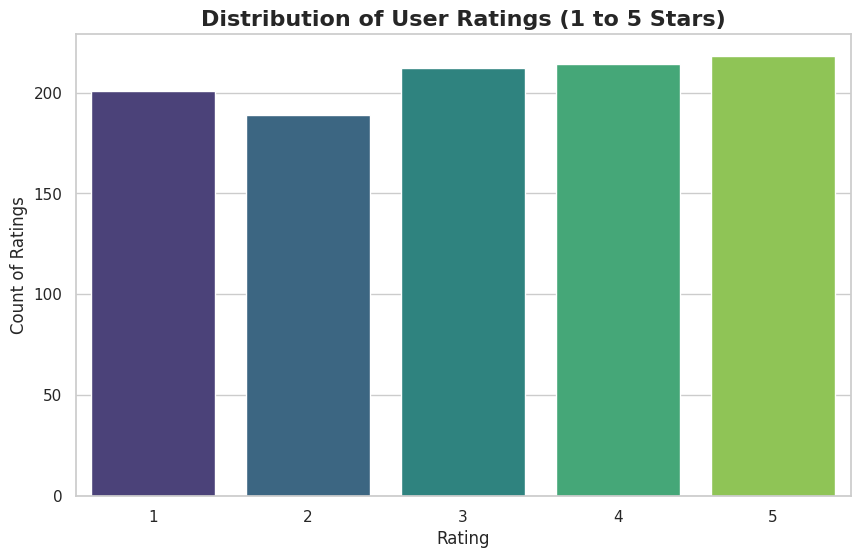

In [7]:
# 1. Distribution of Ratings
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of User Ratings (1 to 5 Stars)', fontsize=16, fontweight='bold')
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Count of Ratings', fontsize=12)

plt.show()

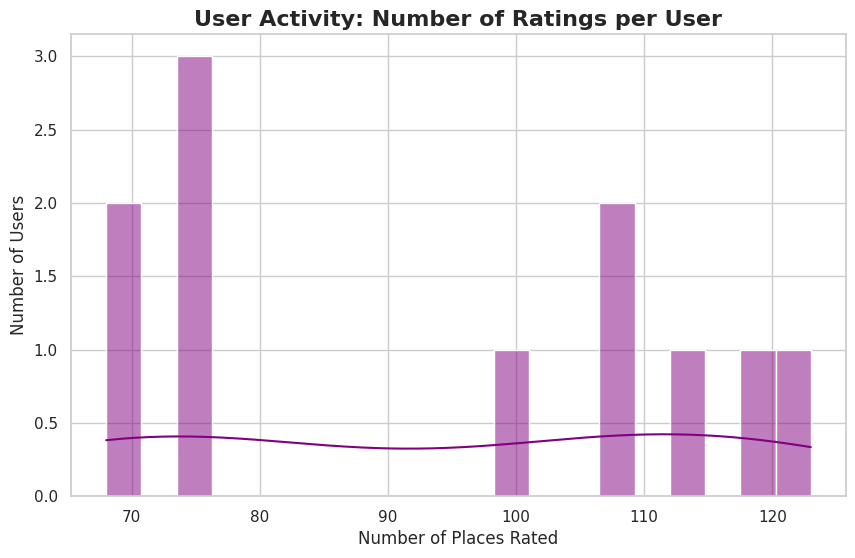

In [8]:
# 2. Number of Ratings per User
plt.figure(figsize=(10, 6))

ratings_per_user = df.groupby('user_id')['rating'].count()
sns.histplot(ratings_per_user, bins=20, kde=True, color='purple')
plt.title('User Activity: Number of Ratings per User', fontsize=16, fontweight='bold')
plt.xlabel('Number of Places Rated', fontsize=12)
plt.ylabel('Number of Users', fontsize=12)

plt.show()

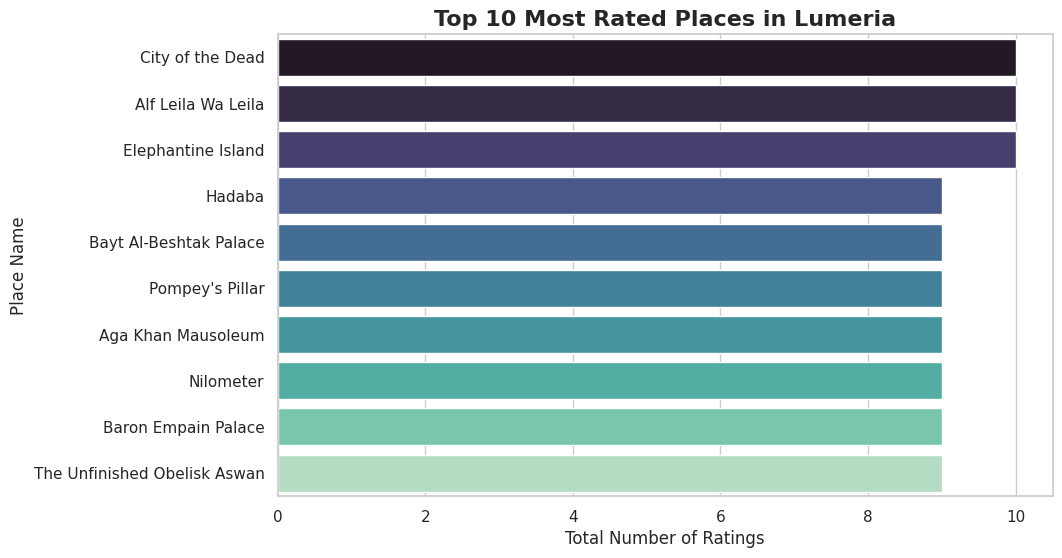

In [9]:
# 3. Top 10 Most Rated Places
plt.figure(figsize=(10, 6))

top_places = df['place_name'].value_counts().head(10)
sns.barplot(x=top_places.values, y=top_places.index, palette='mako')
plt.title('Top 10 Most Rated Places in Lumeria', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Ratings', fontsize=12)
plt.ylabel('Place Name', fontsize=12)

plt.show()

# **4. DATA FILTERING & OPTIMIZATION**
To build a robust Collaborative Filtering model, we need to reduce the sparsity of our dataset. We will filter out users who have rated very few places and places that have been rated by very few users.

In [10]:
# 1. Filter Users: Keep users who have rated at least 5 places
user_counts = df['user_id'].value_counts()
active_users = user_counts[user_counts >= 5].index
filtered_df = df[df['user_id'].isin(active_users)]

In [11]:
# 2. Filter Places: Keep places that have been rated by at least 5 users
place_counts = filtered_df['place_name'].value_counts()
popular_places = place_counts[place_counts >= 5].index
filtered_df = filtered_df[filtered_df['place_name'].isin(popular_places)]

print(f"Records after filtering: {filtered_df.shape[0]}")

Records after filtering: 968


# **5. CREATE THE USER-ITEM MATRIX**
Transforming the filtered dataset into a pivot table where rows represent users, columns represent places, and values represent the ratings. Missing ratings are filled with 0.

In [12]:
# 1. Creating the pivot table
user_place_matrix = filtered_df.pivot_table(index='user_id', columns='place_name', values='rating')

print(f"Initial Matrix shape: {user_place_matrix.shape}")
user_place_matrix.head()

Initial Matrix shape: (11, 143)


place_name,Abu Simbel Temples,Abu al-Abbas al-Mursi Mosque,Abu el-Naga Tombs Northern DraE,Abu el-Naga Tombs Southern Drae,Abusir Necropolis,Aga Khan Mausoleum,Agricultural Museum,Al Sahaba Mosque,Al-Azhar Mosque,Al-Azhar Park,...,Tomb of Pashedu,Tomb of Rakhmire & Tomb of Sennefer,Tomb of Ramose,Tomb of Ramses V & Ramses VI,Tomb of Seti I,Tomb of Tutankhamun,Tombs of al-Khokha,Touristic Promenade,Valley of the Kings,Wekalet Al-Geddawy
user_id,,,,,,,,,,,,,,,,,,,,,
04fab766-306b-4f35-a83e-4655f052392d,4.0,3.0,1.0,NaN,2.0,NaN,1.0,5.0,NaN,NaN,...,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
19e44095-5ef1-4bdf-b9ee-a2268eb91c78,2.0,3.0,3.0,2.0,1.0,2.0,4.0,1.0,NaN,5.0,...,5.0,5.0,4.0,2.0,NaN,2.0,5.0,4.0,5.0,NaN
464b2be6-6cf2-4397-9285-bc8d0af20763,1.0,NaN,4.0,NaN,2.0,3.0,2.0,4.0,1.0,1.0,...,NaN,1.0,NaN,NaN,4.0,4.0,2.0,4.0,4.0,4.0
75e51d21-6876-4997-b8f8-c474c8e191ff,NaN,NaN,NaN,5.0,NaN,3.0,5.0,NaN,NaN,NaN,...,4.0,3.0,NaN,3.0,NaN,4.0,NaN,NaN,NaN,5.0
7fd62523-fc70-4d84-b6e7-304aee6fff7b,3.0,4.0,4.0,3.0,NaN,3.0,4.0,3.0,5.0,2.0,...,NaN,4.0,3.0,NaN,2.0,1.0,5.0,5.0,1.0,5.0


> **Observation:** As seen above, the matrix contains many `NaN` values, which indicates that a user hasn't visited or rated those specific places. For our mathematical model (Cosine Similarity) to work, we need to replace these missing values with `0`.

In [13]:
# 2. Filling NaN values with 0
user_place_matrix.fillna(0, inplace=True)

In [14]:
user_place_matrix.head()

place_name,Abu Simbel Temples,Abu al-Abbas al-Mursi Mosque,Abu el-Naga Tombs Northern DraE,Abu el-Naga Tombs Southern Drae,Abusir Necropolis,Aga Khan Mausoleum,Agricultural Museum,Al Sahaba Mosque,Al-Azhar Mosque,Al-Azhar Park,...,Tomb of Pashedu,Tomb of Rakhmire & Tomb of Sennefer,Tomb of Ramose,Tomb of Ramses V & Ramses VI,Tomb of Seti I,Tomb of Tutankhamun,Tombs of al-Khokha,Touristic Promenade,Valley of the Kings,Wekalet Al-Geddawy
user_id,,,,,,,,,,,,,,,,,,,,,
04fab766-306b-4f35-a83e-4655f052392d,4.0,3.0,1.0,0.0,2.0,0.0,1.0,5.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
19e44095-5ef1-4bdf-b9ee-a2268eb91c78,2.0,3.0,3.0,2.0,1.0,2.0,4.0,1.0,0.0,5.0,...,5.0,5.0,4.0,2.0,0.0,2.0,5.0,4.0,5.0,0.0
464b2be6-6cf2-4397-9285-bc8d0af20763,1.0,0.0,4.0,0.0,2.0,3.0,2.0,4.0,1.0,1.0,...,0.0,1.0,0.0,0.0,4.0,4.0,2.0,4.0,4.0,4.0
75e51d21-6876-4997-b8f8-c474c8e191ff,0.0,0.0,0.0,5.0,0.0,3.0,5.0,0.0,0.0,0.0,...,4.0,3.0,0.0,3.0,0.0,4.0,0.0,0.0,0.0,5.0
7fd62523-fc70-4d84-b6e7-304aee6fff7b,3.0,4.0,4.0,3.0,0.0,3.0,4.0,3.0,5.0,2.0,...,0.0,4.0,3.0,0.0,2.0,1.0,5.0,5.0,1.0,5.0


# **6. CALCULATE COSINE SIMILARITY**
Computing the mathematical similarity between users based on their rating vectors.

In [15]:
# Calculating Cosine Similarity
user_similarity = cosine_similarity(user_place_matrix)

In [16]:
# Converting the result into a DataFrame for easier index matching
user_similarity_df = pd.DataFrame(user_similarity, 
                                  index=user_place_matrix.index, 
                                  columns=user_place_matrix.index)

In [17]:
user_similarity_df.head()

user_id,04fab766-306b-4f35-a83e-4655f052392d,19e44095-5ef1-4bdf-b9ee-a2268eb91c78,464b2be6-6cf2-4397-9285-bc8d0af20763,75e51d21-6876-4997-b8f8-c474c8e191ff,7fd62523-fc70-4d84-b6e7-304aee6fff7b,94186954-4e83-4fe3-be7a-f930f30784c5,ae86ebaf-289d-4f7c-9743-2686dcca7a3f,b97e27e8-7f59-460e-95c3-cc68912eb90b,e23be8f3-890c-406e-91d2-6f63be4854b8,e67a0551-fbed-43d7-afbc-e4e52554d6e5,ff583213-7dba-47eb-9070-258374a87e64
user_id,,,,,,,,,,,
04fab766-306b-4f35-a83e-4655f052392d,1.000000,0.455483,0.480707,0.338609,0.510518,0.484026,0.336950,0.498517,0.384711,0.460197,0.480594
19e44095-5ef1-4bdf-b9ee-a2268eb91c78,0.455483,1.000000,0.592303,0.536071,0.648652,0.553112,0.432088,0.499586,0.466385,0.543944,0.646668
464b2be6-6cf2-4397-9285-bc8d0af20763,0.480707,0.592303,1.000000,0.538823,0.593445,0.567438,0.454530,0.496902,0.494357,0.563220,0.609874
75e51d21-6876-4997-b8f8-c474c8e191ff,0.338609,0.536071,0.538823,1.000000,0.527060,0.472910,0.383653,0.448617,0.452202,0.498048,0.508435
7fd62523-fc70-4d84-b6e7-304aee6fff7b,0.510518,0.648652,0.593445,0.527060,1.000000,0.522426,0.443000,0.472245,0.448929,0.577724,0.584110


# **7. BUILD THE RECOMMENDATION ENGINE**
To make our model production-ready and easily deployable via a FastAPI backend for the Lumeria Flutter app, we encapsulated the entire recommendation logic into a single, robust function. 

**Behind the scenes, this function performs 5 key steps:**
1. **Identify Similar Users:** Retrieves the top users with the highest Cosine Similarity scores to our target user.
2. **Filter Visited Places:** Extracts the list of places the target user has already visited to avoid redundant recommendations.
3. **Calculate Candidate Scores:** Iterates through the places visited by the "similar users". For each unvisited place, it multiplies the similar user's rating by the similarity score.
4. **Aggregate & Rank:** Sums up the scores for each place and sorts them in descending order.
5. **Output Top N:** Returns the highest-scoring places as the final recommendations.

In [18]:
def get_user_recommendations(user_id, top_n=5, similar_users_count=5):
    """
    Recommends places for a user based on the User-Based Collaborative Filtering approach.
    """
    # Check if user exists in our filtered matrix
    if user_id not in user_place_matrix.index:
        return "User not found or filtered out due to low activity. Consider Popularity-Based recommendations."
    
    # 1. Get top N similar users (excluding the user themselves)
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:similar_users_count+1]
    
    # 2. Get the places the target user has already visited/rated
    user_visited = user_place_matrix.loc[user_id]
    visited_places = user_visited[user_visited > 0].index.tolist()
    
    # 3. Calculate score for unvisited places based on similar users' ratings
    recommendations = {}
    
    for sim_user, sim_score in similar_users.items():
        sim_user_ratings = user_place_matrix.loc[sim_user]
        
        for place, rating in sim_user_ratings.items():
            # If the similar user rated it AND our target user hasn't visited it
            if rating > 0 and place not in visited_places:
                if place not in recommendations:
                    recommendations[place] = rating * sim_score
                else:
                    recommendations[place] += rating * sim_score
                    
    # 4. Sort the recommended places by their calculated score in descending order
    sorted_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    
    # 5. Return the top_n place names
    return [place[0] for place in sorted_recommendations[:top_n]]

# **8. TEST THE MODEL**
Testing the recommendation function on a sample user.

In [19]:
# Let's pick a random active user from our matrix
sample_user = user_place_matrix.index[0]

print(f"🎯 Recommendations for User {sample_user}:\n")
recommended_places = get_user_recommendations(user_id=sample_user, top_n=5)

for i, place in enumerate(recommended_places, 1):
    print(f"{i}. {place}")

🎯 Recommendations for User 04fab766-306b-4f35-a83e-4655f052392d:

1. Memphis
2. Botanical Island
3. Saint Catherine's Monastery
4. Al-Azhar Mosque
5. Aga Khan Mausoleum


# **8. INFERENCE VERIFICATION & USER PROFILING** 🕵️‍♀️
To ensure our model is recommending relevant places, we will perform a visual and tabular sanity check on a target user. First, let's look at the places they have already visited and highly rated.

In [20]:
target_user = sample_user 
print(f"🎯 Inference & Verification for User: {target_user}\n" + "="*60)

# 1. Places visited & highly rated by our Target User
target_history = df[(df['user_id'] == target_user) & (df['rating'] >= 4)]
print(target_history[['place_name', 'rating', 'Type Of Site']].to_string(index=False))

🎯 Inference & Verification for User: 04fab766-306b-4f35-a83e-4655f052392d
                       place_name  rating  Type Of Site
      Ras Mohammed National Park        5  Diving Spots
         Mosque of Amr Ebn El-Aas       5  Sacred Sites
                  El Gouna Resort       4        Places
 Eastern Harbor Sunken Monuments        4 Ancient Sites
                   Tomb of Ramose       5 Ancient Sites
           Karnak Temples Complex       4  Sacred Sites
           Sharm El-Sheikh Museum       5       Museums
                   Temple of Isis       4  Sacred Sites
                Prince Taz Palace       4        Places
               Abu Simbel Temples       4  Sacred Sites
                 Al Sahaba Mosque       5  Sacred Sites
                        Nilometer       5        Places
                       Orange Bay       5  Diving Spots
          Temple of Horus at Edfu       4  Sacred Sites
               Sea World Hurghada       5  Diving Spots
                 City of the D

### 📊 Visualizing the User's Preferences
Let's aggregate the types of sites this user prefers to understand their implicit profile.

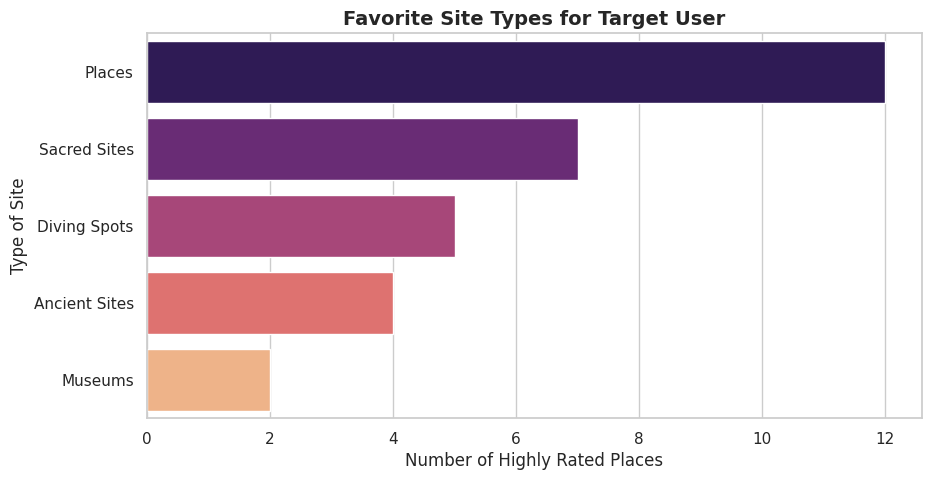

In [21]:
# 2. Visualizing the User's Favorite Categories
plt.figure(figsize=(10, 5))
user_fav_types = target_history['Type Of Site'].value_counts()
sns.barplot(x=user_fav_types.values, y=user_fav_types.index, palette='magma')

plt.title(f"Favorite Site Types for Target User", fontsize=14, fontweight='bold')
plt.xlabel('Number of Highly Rated Places', fontsize=12)
plt.ylabel('Type of Site', fontsize=12)
plt.show()

### 👯‍♂️ Analyzing "The Twins" (Similar Users)
Now, let's identify the most similar users to our target user and see how they rated the places our Collaborative Filtering model just recommended. This proves that our recommendations are grounded in actual data from users with identical tastes.

In [22]:
# 3. The Top Similar Users (The 'Twins')
print("The Top Similar Users (The 'Twins'):")
similar_users = user_similarity_df[target_user].sort_values(ascending=False)[1:4] # Get top 3
for user, score in similar_users.items():
    print(f"User ID: {user[:10]}... | Similarity: {score:.2f}")
print("-" * 60)

# 4. How did these 'Twins' rate the recommended places?
print("How did these 'Twins' rate the recommended places?")
sim_users_ratings = df[(df['user_id'].isin(similar_users.index)) & (df['place_name'].isin(recommended_places))]
print(sim_users_ratings[['user_id', 'place_name', 'rating']].to_string(index=False))

The Top Similar Users (The 'Twins'):
User ID: 7fd62523-f... | Similarity: 0.51
User ID: b97e27e8-7... | Similarity: 0.50
User ID: 94186954-4... | Similarity: 0.48
------------------------------------------------------------
How did these 'Twins' rate the recommended places?
                             user_id                  place_name  rating
7fd62523-fc70-4d84-b6e7-304aee6fff7b             Al-Azhar Mosque       5
7fd62523-fc70-4d84-b6e7-304aee6fff7b          Aga Khan Mausoleum       3
7fd62523-fc70-4d84-b6e7-304aee6fff7b                     Memphis       5
7fd62523-fc70-4d84-b6e7-304aee6fff7b            Botanical Island       3
7fd62523-fc70-4d84-b6e7-304aee6fff7b Saint Catherine's Monastery       5
94186954-4e83-4fe3-be7a-f930f30784c5            Botanical Island       4
94186954-4e83-4fe3-be7a-f930f30784c5 Saint Catherine's Monastery       3
94186954-4e83-4fe3-be7a-f930f30784c5          Aga Khan Mausoleum       4
94186954-4e83-4fe3-be7a-f930f30784c5             Al-Azhar Mosque    